In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

<font size=5, color='red'><b> ch4. 머신러닝모형최적화 </b></font>
# 1절. 변수 선택과 차원 축소
## 1-1 변수선택과 차원축소
- 종속변수에 영향을 주는 변수들을 찾아 학습에 사용할 독립변수의 수를 줄임 
    (어떻게 하면 score를 높일 수 있을지?)
- 과적합과 변수들 사이의 다중공선성(변수들간 강한 상관관계)을 줄일 수 있음 
    * 회귀계수 해석이 어려워짐. 모델 예측력이 좋아도 해석력이 떨어짐(어떤 변수가 제일 큰 요인인지 잘), p값이나 유의성 검정이 왜곡될 수 있음
- 모형의 학습 시간을 줄일 수 있음
- 주성분분석, 상관분석, **분류모형의 feature_importance_, 예측 모형의 coef_**
- SelectKBest : 가장 높은 score에 따라 K개의 특징을 선택

## 1-2 주성분분석(PCA, Principal Component Anaysis)
- 주성분분석은 변수 선택 및 차원축소 방법(기존의 모든 변수를 조합하여 새로운 변수로 만듦) 으로 널리 사용 
- 주성분 분석은 상관관계가 있는 변수들을 선형결합해서 **분산이 극대화된 상관관계가 없는 새로운 변수(주성분)들로 축약**하는 것
- 주성분 분석은 사실 선형대수학이라기보다는 선형대수학의 활용적인 측면이 강하며 영상인식, 통계 데이터분석(주성분 찾기), 데이터 압축, 노이즈제거 등 여러 분야에 사용
- 영상처리에서 많이 활용 : 여러개의 영상 중 대표 이미지를 찾을 때 활용

In [5]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:,:-1], iris.species # 주성분 분석은 독립변수들로만 활용하여 새로운 변수를 조합
iris_X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [17]:
pca = PCA(n_components=2) # 몇 개의 데이터를 필요로 하는 가? : n_components=2 주성분의 개수
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:5]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451]])

In [18]:
pca.components_ # 기존 4개 입력변수에 components_의 값들을 곱해서 더한 값
# 2개의 주성분을 추출하기 위해 2개 행(pca.components_.shape[0] = 2(n_components 값), pca.components_.shape[1] = 4(기존 입력변수 개수))
# 회귀분석 시 loss와 오차를 줄이는 방법 중 하나일 뿐 반드시 해야한다는 의미는 아님

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [19]:
# 설명 분산 : 각 주성분 벡터가 정보량을 얼마나 잘 표현하는 지(설명하는 지)
print("설명 분산 :",pca.explained_variance_)
# 설명 분산을 0~1사이의 비율로 조정된 설명 정도
print("설명 분산 비율 :", pca.explained_variance_ratio_) 
# 본래 4개의 변수들이 100퍼센트 표현하는 걸 얼마나 표현하는 가에 대한 비율 => 일반적으로 100%가 될 수 없음
# 주성분 결과 특성은 97.76852%

설명 분산 : [4.22824171 0.24267075]
설명 분산 비율 : [0.92461872 0.05306648]


## 1-3. 상관관계 확인
- 각 변수들 끼리 상관관계를 확인(시각화), 종속변수와 상관관계가 높은 변수들만 선택하는 방법

In [23]:
import pandas as pd
redwine = pd.read_csv('data/winequality-red.csv', sep=';') # delimiter도 가능
redwine.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


In [24]:
corr = redwine.corr()
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


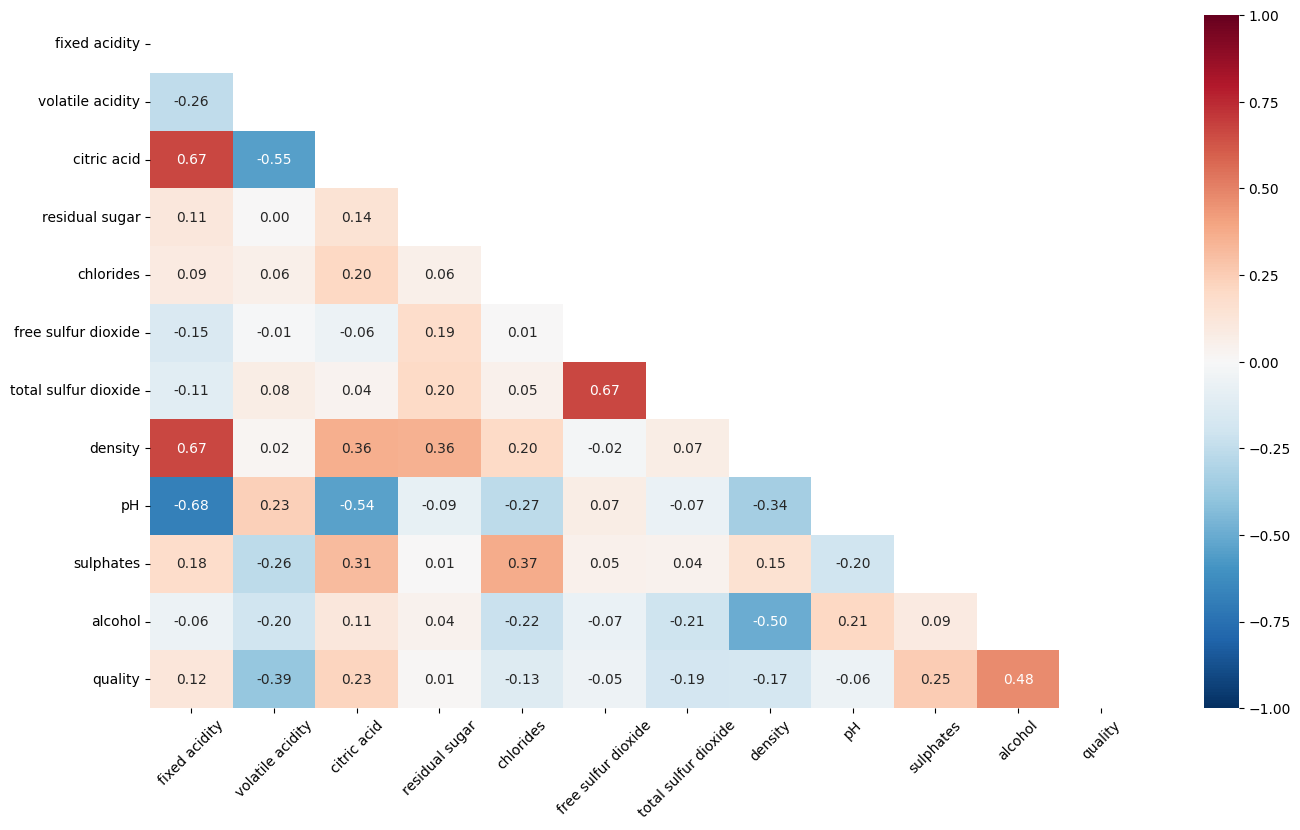

In [40]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(16,9))
mask = np.triu(np.ones_like(corr),k=0) # k=0 : 0,0 부터 삼각형 시작 k=1 : 0,1 부터 삼각형 시작
sns.heatmap(corr,annot =True ,mask=mask,cmap = 'RdBu_r', fmt='.2f', vmin=-1, vmax=1)
plt.xticks(rotation=45)
plt.show()

## 1-4. 분류모형의 feature_importance_
- 분류모형의 feature_importance_ 속성은 각 독립변수들이 종속변수에 영향을 주는 정도
- LogisticRegression이나 SVC, MLP, GaussianNB 등은 feature_importance_ 속성이 없음
- DecsissionTree 등 그외의 대부분 머신러닝 분류모형에는 해당 속성 존재

In [44]:
from sklearn.model_selection import train_test_split
X = redwine.iloc[:,:-1]
y = redwine.iloc[:,-1]
# X.shape, y.shape
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size= 0.3, stratify=y)
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((1119, 11), (1119,), (480, 11), (480,))

In [47]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10, # 의사결정나무 n_estimator개로 데이터를 샘플링해서 병렬처리해 가장 좋은 트리를 알고리즘으로 선택
#                                     criterion='gini',
#                                     max_depth=None,
#                                     min_samples_split=2,
#                                     min_samples_leaf=1,
#                                     min_weight_fraction_leaf=0.0,
#                                     max_features='sqrt',
#                                     max_leaf_nodes=None,
#                                     min_impurity_decrease=0.0,
#                                     bootstrap=True,
#                                     oob_score=False,
#                                     n_jobs=None,
#                                     random_state=None,
#                                     verbose=0,
#                                     warm_start=False,
#                                     class_weight=None,
#                                     ccp_alpha=0.0,
#                                     max_samples=None
                                 )
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10)

In [48]:
rf_model.feature_importances_

array([0.06690952, 0.11424581, 0.07018776, 0.07607361, 0.07762964,
       0.05840563, 0.10934016, 0.09673986, 0.0749165 , 0.11412288,
       0.14142865])

In [53]:
features = pd.DataFrame(data = np.c_[X.columns, rf_model.feature_importances_],
                       columns=['feature','importance'])
features['importance'].sum()

1.0

In [61]:
features.sort_values(by=['importance'], ascending=False, inplace=True)
features.reset_index(drop=True, inplace=True)

In [63]:
features.head()

,feature,importance
0,alcohol,0.141429
1,volatile acidity,0.114246
2,sulphates,0.114123
3,total sulfur dioxide,0.10934
4,density,0.09674


### feature_importance_를 이용한 변수 중요도 시각화

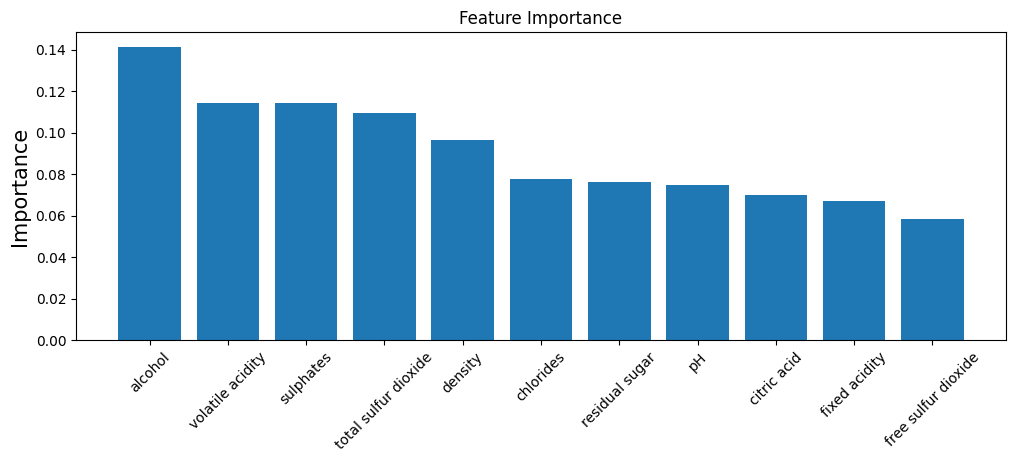

In [69]:
# features
plt.figure(figsize=(12,4))
plt.bar(features.feature, features.importance)
plt.xticks(rotation=45, fontsize=10)
plt.ylabel('Importance', fontsize=15)
plt.title("Feature Importance")
plt.show()

#### feature_importance_ 시각화
- 누적합을 사용해서 경향성을 판단한다

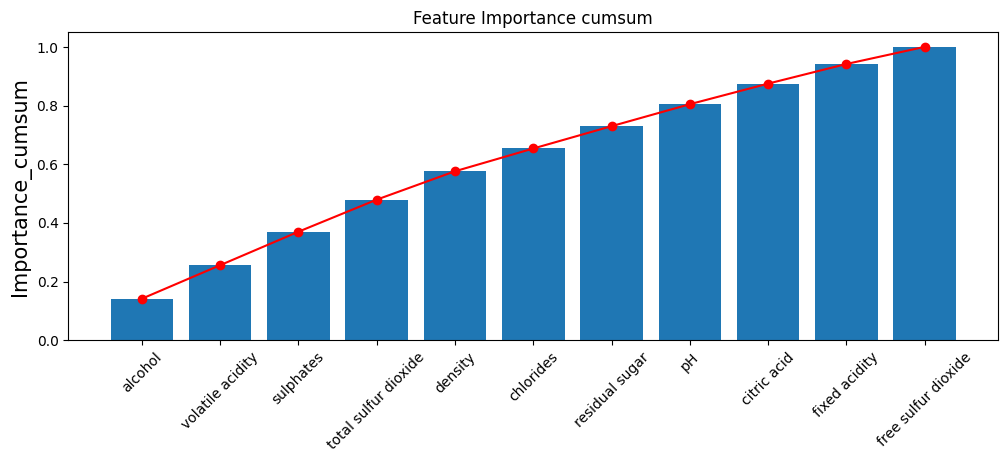

In [77]:
# features.importance 누적합
# l = [1,2,3]
# np.cumsum(l)
y_stack = np.cumsum(features.importance)
np.c_[features.importance, y_stack]

plt.figure(figsize=(12,4))
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, color='red',marker='o')
plt.xticks(rotation=45, fontsize=10)
plt.ylabel('Importance_cumsum', fontsize=15)
plt.title("Feature Importance cumsum")
plt.show()

#### 위 그래프가 직선 상승형에 가깝다면 모든 요소가 중요하게 작용한다. 
#### 만약 그래프에서 기울기 변화가 없어지는 시점이 발생하면 그 때는 feature를 축소함을 고려한다

### RFE(Recursive Feature Elimination 방식)
- RFE 클래스를 이용 : 중요도에 따라 중요도가 낮은 변수부터 하나씩 제거해 가면서 최종 선택된 변수 개수만큼 중요도가 높은 변수를 찾는다.

In [84]:
# 5개 특징이 남을 때 까지 변수를 제거(기준 : feature_importance_ 기준)
# train_X # feature cumsum 그래프가 로그함수 처럼 나왔다 가정
from sklearn.feature_selection import RFE
rfe = RFE(rf_model,
         n_features_to_select=5).fit(train_X,train_y)
rfe.get_support()

array([False,  True, False, False, False, False,  True,  True, False,
        True,  True])

In [88]:
features_rfe = pd.DataFrame(np.c_[X.columns, rfe.get_support()], columns=['feature','selected'])
features_rfe

,feature,selected
0,fixed acidity,False
1,volatile acidity,True
2,citric acid,False
3,residual sugar,False
4,chlorides,False
5,free sulfur dioxide,False
6,total sulfur dioxide,True
7,density,True
8,pH,False
9,sulphates,True


In [89]:
features_rfe[features_rfe['selected']==True]

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True


## 1-5. SelectKBest
- 가장 높은 score에 따라 k개 feature 선택

In [93]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2
X = iris.iloc[:,:-1].values
y = iris.iloc[:,-1].values
X.shape, y.shape

((150, 4), (150,))

In [95]:
cols_X = iris.columns[:-1].tolist() # feature name
cols_y = iris.columns[-1].tolist() # target

In [96]:
# 가장 중요한 feature 1개 추출
# f_classif : y는 범주형. x는 연속형
# chi2 : y는 범주형, x는 범주형이거나 양의 실수
# mutual_info : 비선형 데이터 고려 => 이미지 등
X_new = SelectKBest(f_classif, # x가 연속형
                   k=1, # 추출할 feature의 개수
                   ).fit_transform(X,y)

In [98]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [97]:
X_new # petal_length

array([[1.4],
       [1.4],
       [1.3],
       [1.5],
       [1.4],
       [1.7],
       [1.4],
       [1.5],
       [1.4],
       [1.5],
       [1.5],
       [1.6],
       [1.4],
       [1.1],
       [1.2],
       [1.5],
       [1.3],
       [1.4],
       [1.7],
       [1.5],
       [1.7],
       [1.5],
       [1. ],
       [1.7],
       [1.9],
       [1.6],
       [1.6],
       [1.5],
       [1.4],
       [1.6],
       [1.6],
       [1.5],
       [1.5],
       [1.4],
       [1.5],
       [1.2],
       [1.3],
       [1.4],
       [1.3],
       [1.5],
       [1.3],
       [1.3],
       [1.3],
       [1.6],
       [1.9],
       [1.4],
       [1.6],
       [1.4],
       [1.5],
       [1.4],
       [4.7],
       [4.5],
       [4.9],
       [4. ],
       [4.6],
       [4.5],
       [4.7],
       [3.3],
       [4.6],
       [3.9],
       [3.5],
       [4.2],
       [4. ],
       [4.7],
       [3.6],
       [4.4],
       [4.5],
       [4.1],
       [4.5],
       [3.9],
       [4.8],
      

# 2절. 파라미터 선택
- 하이퍼 파라미터 : 사용자가 직접 설정할 수 있는 파라미터. 최적의 결과를 내는 하이퍼 파라미터 값 찾기
    1. valudation_curve() : 하나의 파라미터 최적값 찾기 함수
    2. GridSearchCV() : 파라미터 n개 최적값 찾기 클래스(가장 높은 score를 내는 모형까지 찾아줌) => 시간소요가 크다

## 2-1. validation_curve()
- param_name, param_range(리스트), scoring(accuracy 기준? recall 기준? 성능지표기준 문자열) 매개변수로 받아 최적의 성능을 계산

In [112]:
# data
from sklearn.datasets import load_digits
digits = load_digits()
# digits.data : (1797,64) 배열 => 8x8 이미지를 1차원으로 : 독립변수
# digits.images.shape (1797, 8, 8) 배열
# digits.target.shape # (1797,) 배열 : 타겟변수
# digits.target_names # 타겟변수의 종류

X, y = digits.data, digits.target
X.shape, y.shape

((1797, 64), (1797,))

In [125]:
np.equal(X[0].reshape(8,8), digits.images[0])

array([[ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True]])

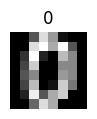

In [132]:
# 데이터가 정말 숫자형태인지 체크
plt.figure(figsize=(1,1))
plt.imshow(digits.images[0], cmap='gray')
plt.title(digits.target[0])
plt.axis('off')
plt.show()

In [137]:
from sklearn.svm import SVC
svc = SVC(
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=True, # default False, 판별 모형이어도 predict_proba 가능
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=None,
    )
svc.fit(X,y)

SVC(probability=True)

In [139]:
svc.predict([X[0]]) # 예측값

array([0])

In [142]:
print(svc.classes_)
print(svc.predict_proba([X[0]])) # 예측 확률

[0 1 2 3 4 5 6 7 8 9]
[[9.91008640e-01 2.07903106e-04 4.98114915e-04 8.49001584e-04
  6.27985702e-04 1.48313383e-03 7.47830905e-04 9.53333285e-04
  7.51403952e-04 2.87265264e-03]]


In [146]:
for c, p in zip(svc.classes_, svc.predict_proba(X[0].reshape(1,-1))[0]) :
    print("{}일 확률 : {:.3f}".format(c,p))

0일 확률 : 0.991
1일 확률 : 0.000
2일 확률 : 0.000
3일 확률 : 0.001
4일 확률 : 0.001
5일 확률 : 0.001
6일 확률 : 0.001
7일 확률 : 0.001
8일 확률 : 0.001
9일 확률 : 0.003


In [148]:
svc.score(X,y) # accuracy

0.996661101836394

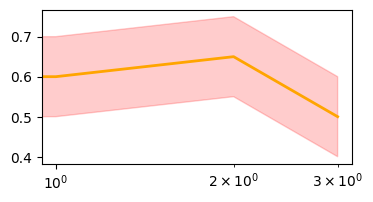

In [155]:
# SVC의 파라미터 C값의 최적값 찾기
range_ = np.array([0,1,2,3])
score = np.array([0.5,0.6,0.65,0.5])
plt.figure(figsize=(4,2))
plt.semilogx(range_,score, color='orange', lw=2)
plt.fill_between(range_, score-0.1, score+0.1, color='red', alpha=0.2)
plt.show()

In [165]:
# svc() 모형에서 c파라미터 값을 다음의 범위 중 제일 좋은 c값?
# param_range = [0.0000006,..................., 0.1]
# param_range = np.linspace(10e-6, 10e-1, 10)
param_range = np.logspace(-6, -1, 10) # np.logspace => 10의 -6승부터 10의 -1승까지 로그 간격으로 균등 분포 10개
# c에 param_range를 넣으면 더 세밀하게 모델을 나눌건지, 아니면 부드럽게 모델을 나눌건지 선택하는 내용으로 세밀해지면 과적합의 위험
param_range

array([1.00000000e-06, 3.59381366e-06, 1.29154967e-05, 4.64158883e-05,
       1.66810054e-04, 5.99484250e-04, 2.15443469e-03, 7.74263683e-03,
       2.78255940e-02, 1.00000000e-01])

In [170]:
%%time
from sklearn.model_selection import validation_curve

train_score, test_score = validation_curve(SVC(), # 예측모형
                                            X,
                                            y,
                                            param_name='gamma', # 어떤 파라미터의 최적값을 찾을것인지
                                            param_range=param_range, # 1d 리스트형태로 파라미터 전달
                                            groups=None,
                                            cv=10, # 데이터를 cv값 등분한 후 테스트데이터셋을 바꿔가면서 교차검증 * cross validate
                                            scoring='accuracy',
                                            n_jobs=-1, # 현시스템의 모든 core를 사용
                                            pre_dispatch='all',
                                            verbose=0,
                                            fit_params=None,)
# 전체 validation_curve 실행 횟수는 len(param_range) * cv = 100회

CPU times: total: 625 ms
Wall time: 18.5 s


In [173]:
test_score.shape, train_score.shape

((10, 10), (10, 10))

In [180]:
train_score_mean = np.mean(train_score, axis=1) # 행별평균
test_score_mean = np.mean(test_score, axis=1) # 행별평균
train_score_std = np.std(train_score, axis=1) # 행별 표준편차
test_score_std = np.std(test_score, axis=1) # 행별 표준편차
print('train_score_mean :',train_score_mean)
print('test_score_mean :',test_score_mean)
test_score_std

train_score_mean : [0.13836306 0.72045751 0.93439655 0.96939318 0.98775736 0.99789765
 1.         1.         1.         1.        ]
test_score_mean : [0.13871508 0.70395717 0.90871198 0.94264742 0.95880509 0.97495655
 0.97496586 0.80522036 0.19709497 0.10463687]


array([0.06458693, 0.02805082, 0.03841992, 0.03207261, 0.02606765,
       0.02054497, 0.01863724, 0.05734476, 0.0509597 , 0.00764792])

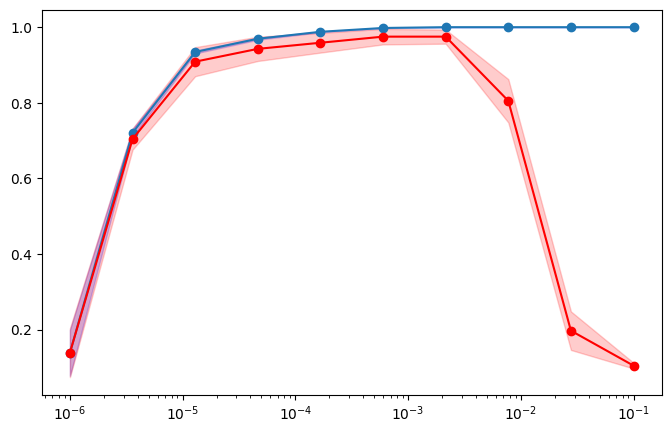

In [189]:
# 표준편차가 너무 크지 않은 지 체크하는 시각화
plt.figure(figsize=(8,5))
plt.semilogx(param_range, train_score_mean, label = 'train_score_mean', marker='o')
plt.fill_between(param_range, train_score_mean-train_score_std, train_score_mean+train_score_std, alpha=0.2, color='blue')
plt.semilogx(param_range, test_score_mean, label = 'test_score_mean', color='red', marker='o')
plt.fill_between(param_range, test_score_mean-test_score_std, test_score_mean+test_score_std, alpha=0.2, color='red')
plt.show()

In [190]:
test_score_mean.argmax()

6

In [194]:
# validiation_curve()를 통해 구한 최적의 gamma 값
gamma = param_range[test_score_mean.argmax()]
gamma

0.0021544346900318843

In [195]:
model = SVC(gamma=gamma).fit(X,y)
model.score(X,y)

1.0

## 2-2. GridSearchCV
- 복수 개의 하이퍼 파라미터 최적화 클래스
- 모형도 반환
- fit(), score(), predict(), predict_proba(), decision_function()

In [199]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest
from sklearn.svm import SVC

# data => GridSearchCV는 시간 소요가 많이 커서 데이터를 더 작은 redwine 데이터 사용
redwine.head()
redwine_X, redwine_y = redwine.iloc[:,:-1], redwine.iloc[:,-1]
redwine_X.shape, redwine_y.shape

((1599, 11), (1599,))

In [201]:
%%time
# SelectKBest로 최적의 독립변수 K개 찾음 -> SVC()에서 최적의 c값을 찾음
selection = SelectKBest(k=1) # 가장 평가 점수가 높은 k개를 찾음
svc = SVC(kernel='linear') # 직선으로 나누는 가장 단순한 분류모형 => 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'...
pipeline = Pipeline([('select',selection),('svc',svc)])
param_grid = dict(
    select__k = [4,5,6,7,8,9,10,11],
    svc__C = [0.1, 1, 10], # SVC에서 C값을 list속 값으로 시도해라 => 오차범위 허용 정도(C가 크면 엄격, C가 작으면 허용범위가 넓다)
)
grid_search = GridSearchCV(estimator=pipeline, # 어떤 값을 찾을 지 Pipeline
                            param_grid=param_grid, # 파라미터들
                            cv=2,
                            verbose=2, # 로그출력을 자세히
                            n_jobs=-1,
                           ).fit(redwine_X, redwine_y)
grid_search.fit(redwine_X.values, redwine_y.values)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
Fitting 2 folds for each of 24 candidates, totalling 48 fits
CPU times: total: 42.2 s
Wall time: 6min 15s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('select', SelectKBest(k=1)),
                                       ('svc', SVC(kernel='linear'))]),
             n_jobs=-1,
             param_grid={'select__k': [4, 5, 6, 7, 8, 9, 10, 11],
                         'svc__C': [0.1, 1, 10]},
             verbose=2)

In [202]:
grid_search.best_params_

{'select__k': 9, 'svc__C': 1}

In [204]:
model = grid_search.best_estimator_
model.score(redwine_X.values,redwine_y.values)

0.5878674171357098

In [205]:
model = SVC().fit(redwine_X.values,redwine_y.values)
model.score(redwine_X.values,redwine_y.values)

0.5103189493433395

# 3절. 데이터 불균형 해소
- imbalanced.smote() 활용

* 절대적인 데이터가 많다면 언더샘플링(균형을 맞춰서 데이터를 추출)
* 데이터의 양이 부족하다면 smote(가상의 데이터를 생성)

- 단순 오버/언더 샘플링
- 단, 단순 오버 샘플링 시 소수의 데이터를 복사하면 과적합 우려
- 오버샘플링하는 방법 : SMOTE
## 3-1. SMOTE를 이용한 오버샘플링 전

In [266]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000,
                          n_features= 10, # 독립변수 개수
                          n_informative= 5, # 종속변수에 영향을 미치는 독립변수
                          n_redundant = 0,
                          n_clusters_per_class = 1,
                          n_classes=2,
                          weights = [0.99,0.01], # 각 클래스에 할당된 표본
                          random_state=42
                          )
y.mean()

0.014

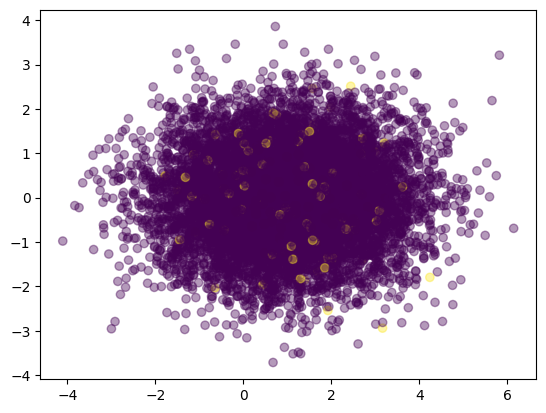

In [267]:
plt.scatter(X[:,0],X[:,1],c=y, alpha=0.4)

In [268]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 10), (7000,), (3000, 10), (3000,))

In [217]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
                             n_estimators=100,
                            criterion='gini',
                            max_depth=None,
                            min_samples_split=2,
                            min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0,
                            max_features=2,
                            max_leaf_nodes=None,
                            min_impurity_decrease=0.0,
                            bootstrap=True,
                            oob_score=False,
                            n_jobs=None,
                            random_state=42,
                            verbose=0,
                            warm_start=False,
                            class_weight=None,
                            ccp_alpha=0.0,
                            max_samples=None,
                                 )
rf_model.fit(X_train,y_train)

RandomForestClassifier(max_features=2, random_state=42)

In [220]:
rf_model.score(X_test, y_test)
y_hat = rf_model.predict(X_test)
y_hat

array([0, 0, 0, ..., 0, 0, 0])

In [222]:
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(y_test, y_hat)

array([[2958,    0],
       [  34,    8]], dtype=int64)

In [224]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2958
           1       1.00      0.19      0.32        42

    accuracy                           0.99      3000
   macro avg       0.99      0.60      0.66      3000
weighted avg       0.99      0.99      0.98      3000



## 3-2. SMOTE를 이용한 전체 오버샘플링 후 데이터 셋 분리
- imbalanced-learn lib 필요

In [236]:
# 0그룹과 1그룹의 개수
df = pd.DataFrame(np.c_[X,y])
df.iloc[:,-1].value_counts()

0.0    9860
1.0     140
Name: 10, dtype: int64

In [246]:
from imblearn.over_sampling import SMOTE

sm = SMOTE() # default 0 그룹 : 1그룹 = 1 : 1
# sm = SMOTE(sampling_strategy={0:9860, 1:420}) # 0그룹 그대로(9860개), 1그룹 420개
X_resampled, y_resampled = sm.fit_resample(X,y)
X_resampled.shape, y_resampled.shape, y_resampled.sum()

((19720, 10), (19720,), 9860)

In [247]:
 pd.DataFrame(np.c_[X_resampled,y_resampled]).iloc[:,-1].value_counts()

0.0    9860
1.0    9860
Name: 10, dtype: int64

In [256]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled,y_resampled, test_size=0.3, stratify=y_resampled, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((13804, 10), (13804,), (5916, 10), (5916,))

In [257]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
                             n_estimators=100,
                            criterion='gini',
                            max_depth=None,
                            min_samples_split=2,
                            min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0,
                            max_features=2,
                            max_leaf_nodes=None,
                            min_impurity_decrease=0.0,
                            bootstrap=True,
                            oob_score=False,
                            n_jobs=None,
                            random_state=42,
                            verbose=0,
                            warm_start=False,
                            class_weight=None,
                            ccp_alpha=0.0,
                            max_samples=None,
                                 )
rf_model.fit(X_train,y_train)

RandomForestClassifier(max_features=2, random_state=42)

In [258]:
rf_model.score(X_test, y_test)
y_hat = rf_model.predict(X_test)
y_hat

array([1, 0, 0, ..., 1, 1, 1])

In [262]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_hat).sum())
confusion_matrix(y_test, y_hat)

5916


array([[2952,    6],
       [  39, 2919]], dtype=int64)

In [260]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2958
           1       1.00      0.99      0.99      2958

    accuracy                           0.99      5916
   macro avg       0.99      0.99      0.99      5916
weighted avg       0.99      0.99      0.99      5916



### 제일 좋은 건 위 처럼 전체 데이터를 1:1로 만들기 보다 train으로 나눈 후 채우는 게 효율적임

## 3-3. 가중치제어
- 자료 불균형 처리의 또 다른 방법
- sklearn의 예측 모형에서 class_weight 매개변수를 설정
- 불균형 자료에 대해 가중치를 높게 설정해서 중요한 것 처럼 느껴지게 만드는 방법

In [272]:
rf_model = RandomForestClassifier(n_estimators=100,
                                 max_features=2,
                                 class_weight='balanced', # {0 : 1, 1 : 1.4}, # 1그룹을 1.4배 더 중요하게 학습, 잘모르겠으면 balanced 사용
                                 random_state=42,
                                 )
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_features=2, random_state=42)

In [273]:
rf_model.score(X_test, y_test)

0.988

# 4절. 최적모형탐색 => 앙상블 모형

- 목적 : 여러 분류모형을 하나의 메타 분류 모델로 연결하여 개별 모형보다 더 좋은 일반화 성능을 달성
- 방법 : 
    * 하나의 메타 분류 알고리즘 이용 : 배깅(bagging), 부스팅(boosting)
    * 여러 분류 알고리즘을 이용 : 다수결 투표
- 배깅 vs 부스팅 
    * 배깅 : => 메타 모델 : 여러 의사결정트리에서 데이터를 복원추출로(데이터중복가능!) 선정한 데이터를 가져와서 feature를 선정한 만큼 사용해서 여러 예시 모델들 병렬로 학습 -> 모델 별 결과에 따라 점수를 가감해서 가장 점수가 높은 모델로 predict. 
        - 복원 추출로 데이터를 선별해 병렬학습 후 score가 높은모델에 가중치 부여
        - 과적합을 줄일 수 있음.
        - 데이터가 충분할 때 과적합을 방지하면서 안정적인 모델이 필요할 때
        - 대표적으로 RandomForestClassifier, BaggingClassifier
    * 부스팅 : => 배깅과 다르게 병렬처리 하지 않음. 여러 모델에서 틀린 모델만 학습을 함
        - 순차적으로 모델 학습. 앞의 모델에서 틀린 데이터의 50%를 다음 모델에서 재학습
        - 가중치를 오답에 둠 : 오답에 집중
        - 성능 극대화
        - 성능 극대화해야 하는데 데이터가 비교적 부족하거나 복잡한 패턴의 학습을 해야할 경우

## 4-1. 배깅알고리즘

In [276]:
wine_df = pd.read_csv('data/wine.csv')
wine_df.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,0D280/0D315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [280]:
X = wine_df.iloc[:,1:]
y = wine_df['Class label']
X.shape, y.shape

((178, 13), (178,))

In [281]:
y.value_counts() # 데이터 불균형 여부 체크

2    71
1    59
3    48
Name: Class label, dtype: int64

In [287]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(X,y,test_size=0.3,stratify=y,random_state=1)

In [288]:
# DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(criterion='entropy',random_state=1).fit(train_X, train_y)
tree_model.score(test_X, test_y)

0.9074074074074074

In [289]:
# BaggingClassifier
from sklearn.ensemble import BaggingClassifier
bag_model = BaggingClassifier(estimator=tree_model,
                             n_estimators=500,
                             bootstrap=True, # 복원추출을 허용 만약 False사용 시 Bagging Algorythm X => 검증셋이 사라짐
                             random_state=1,
                              bootstrap_features= False, # 모든 feature를 사용해서 학습
                             ).fit(train_X, train_y)
bag_model.score(test_X, test_y)

0.9629629629629629

In [290]:
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier().fit(train_X, train_y)
rf_model.score(test_X, test_y)

1.0

### 배깅 알고리즘 시 0.632 규칙
- 복원추출 시 확인할 수 있는 데이터는 63.2% 정도

In [330]:
len(set(np.random.choice(10000,10000, replace=True))) # 10개 데이터를 10개 복원추출로 뽑기

6334

In [408]:
N = 1000000
len(set(np.random.choice(N,N)))/N

0.632442

## 4-2. 임의의 데이터를 만들어 최적 모형 탐색

In [435]:
X, y = make_classification(n_samples=1000,
                          n_classes=2,
                          n_features=10,
                          n_informative=5,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          weights=[0.9, 0.1], # 0 : 90% , 1 : 10%
                          random_state=42)

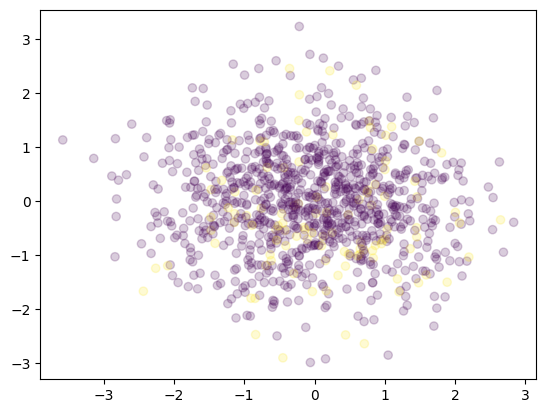

In [436]:
plt.scatter(X[:,0],X[:,1],c=y,alpha=0.2)

In [437]:
train_X, test_X, train_y, test_y = train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)
sm = SMOTE()
resampled_X, resampled_y = sm.fit_resample(train_X, train_y)
resampled_X.shape, resampled_y.shape, test_X.shape, test_y.shape

((1246, 10), (1246,), (300, 10), (300,))

In [418]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
def model_measure(model, train_X = resampled_X, train_y =resampled_y, test_X = test_X, test_y = test_y) :
    '''매개변수로 들어온 model 학습 후 accuracy, precision, recall, f1_score를 반환'''
    model.fit(train_X, train_y)
    pred = model.predict(test_X)
    return f"정확도 : {accuracy_score(test_y, pred):.3f}, 정밀도 : {precision_score(test_y, pred):.3f}, 재현율 : {recall_score(test_y, pred):.3f}, f1 : {f1_score(test_y, pred):.3f}"

In [419]:
model_measure(RandomForestClassifier(n_estimators=100,max_features=2,random_state=42))

'정확도 : 0.983, 정밀도 : 0.942, 재현율 : 0.890, f1 : 0.915'

In [420]:
model_measure(SVC(random_state=42))

'정확도 : 0.988, 정밀도 : 0.957, 재현율 : 0.929, f1 : 0.943'

## 4-3. 부스팅 알고리즘
- AdaBoost, SGB, LGBM, CatBoost

In [421]:
from sklearn.ensemble import AdaBoostClassifier
model_measure(AdaBoostClassifier())

'정확도 : 0.965, 정밀도 : 0.782, 재현율 : 0.919, f1 : 0.845'

In [423]:
from xgboost import XGBClassifier
model_measure(XGBClassifier(max_depth=10, # tree의 깊이
                           n_estimators = 100, # 나무 개수
                           learning_rate = 0.01, # 학습율
                           ))

'정확도 : 0.968, 정밀도 : 0.826, 재현율 : 0.874, f1 : 0.849'

In [434]:
from lightgbm import LGBMClassifier
model_measure(LGBMClassifier(n_estimators=1000,
                            learning_rate=0.01,
                            max_depth=1000,
                            force_col_wise=True,
                            verbose=0))

'정확도 : 0.986, 정밀도 : 0.949, 재현율 : 0.913, f1 : 0.931'

## 4-4. 투표를 이용한 앙상블

- voting = 'hard' : 다수결로 투표
- voting = 'sofr' : 확률의 합으로 결과를 도출

- hard 방식의 경우 짝수 동점표 예방을 위해 홀수 개수의 모델을 사용함. 보통 3개

In [438]:
X, y = make_classification(n_samples=200,
                          n_classes=2,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_clusters_per_class=1,
                          random_state=42)
train_X, test_X, train_y, test_y = train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)

In [440]:
rf_model = RandomForestClassifier(max_features=2, random_state=42)
xbm_model = XGBClassifier(max_depth=10, n_estimators = 100, learning_rate = 0.01, eval_metric='logloss') # lr => 0.01 ~ 0.2 안정적인 학습
lgbm_model = LGBMClassifier(n_estimators = 100, force_col_wise=True, verbose=0)
print(model_measure(rf_model))
print(model_measure(xbm_model))
print(model_measure(lgbm_model))

정확도 : 0.983, 정밀도 : 0.942, 재현율 : 0.890, f1 : 0.915
정확도 : 0.968, 정밀도 : 0.826, 재현율 : 0.874, f1 : 0.849
정확도 : 0.987, 정밀도 : 0.953, 재현율 : 0.916, f1 : 0.934


In [442]:
%%time
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(estimators=[('rfm',rf_model),
                                           ('xbm',xbm_model),
                                           ('lgb',lgbm_model)],
                               voting='hard',
                               n_jobs=-1)

voting_model.fit(resampled_X,resampled_y)

CPU times: total: 812 ms
Wall time: 5.27 s


VotingClassifier(estimators=[('rfm',
                              RandomForestClassifier(max_features=2,
                                                     random_state=42)),
                             ('xbm',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None, gamma=None,
                                            gpu_id=None, grow_polic...
                                            interaction_constraints=None,
                                            learning_rate=0.01, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=10,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            predictor=None, random_state=None, ...)),
                             ('lgb',
                              LGBMClassifier(force_col_wise=True, verbose=0))],
                 n_jobs=-1)

In [445]:
model_measure(voting_model)

'정확도 : 0.984, 정밀도 : 0.939, 재현율 : 0.900, f1 : 0.919'

In [446]:
%%time
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(estimators=[('rfm',rf_model),
                                           ('xbm',xbm_model),
                                           ('lgb',lgbm_model)],
                               voting='soft',
                               n_jobs=-1)

voting_model.fit(resampled_X,resampled_y)
model_measure(voting_model)

CPU times: total: 1.86 s
Wall time: 9.1 s


'정확도 : 0.985, 정밀도 : 0.940, 재현율 : 0.916, f1 : 0.928'